<a href="https://colab.research.google.com/github/saicharangowd40-ops/prod-tech/blob/main/Prod_tech_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:


import numpy as np

print("======================================")
print("     FACTORY PRODUCTION PLANNER")
print("======================================")

# Input: machine hours available
print("\nEnter available hours for each machine:")
m1 = float(input("Machine 1 hours: "))
m2 = float(input("Machine 2 hours: "))
m3 = float(input("Machine 3 hours: "))

# Input: time required by each product on each machine
print("\nEnter machine hours required for each product:")

print("\nProduct 1:")
p1_m1 = float(input("Machine 1: "))
p1_m2 = float(input("Machine 2: "))
p1_m3 = float(input("Machine 3: "))

print("\nProduct 2:")
p2_m1 = float(input("Machine 1: "))
p2_m2 = float(input("Machine 2: "))
p2_m3 = float(input("Machine 3: "))

print("\nProduct 3:")
p3_m1 = float(input("Machine 1: "))
p3_m2 = float(input("Machine 2: "))
p3_m3 = float(input("Machine 3: "))

# Coefficient matrix A
A = np.array([
    [p1_m1, p2_m1, p3_m1],
    [p1_m2, p2_m2, p3_m2],
    [p1_m3, p2_m3, p3_m3]
], dtype=float)

# Available machine hours B
B = np.array([m1, m2, m3], dtype=float)

# Augmented matrix [A | B]
AB = np.column_stack((A, B))

# Calculate ranks
rank_A = np.linalg.matrix_rank(A)
rank_AB = np.linalg.matrix_rank(AB)

print("\n======================================")
print("MATHEMATICAL MODEL")
print("======================================")

print("\nCoefficient Matrix A:")
print(A)

print("\nAvailable Hours Matrix B:")
print(B)

print("\nAugmented Matrix [A | B]:")
print(AB)

print("\nRank of A =", rank_A)
print("Rank of [A|B] =", rank_AB)

# Check consistency
if rank_A == rank_AB:
    print("\nRESULT: The system is CONSISTENT.")

    # Solve AX = B
    if rank_A == 3:
        X = np.linalg.solve(A, B)

        print("\nProduction quantities:")
        print("Product 1 =", round(X[0], 2))
        print("Product 2 =", round(X[1], 2))
        print("Product 3 =", round(X[2], 2))

        # Check for negative production
        if np.any(X < 0):
            print("\nWARNING:")
            print("The mathematical solution contains negative production.")
            print("This is not physically meaningful in a factory.")

        # Calculate machine usage
        usage = A @ X

        print("\nMachine usage:")
        for i in range(3):
            print(
                f"Machine {i+1}: "
                f"{usage[i]:.2f} / {B[i]:.2f} hours"
            )

    else:
        print("\nThe system has infinitely many solutions.")
        print("Additional production constraints are required.")

else:
    print("\nRESULT: The system is INCONSISTENT.")
    print("The available machine hours cannot satisfy all equations.")

    print("\nPossible bottleneck machines:")

    # Test each machine equation against the other two
    for i in range(3):
        other = [j for j in range(3) if j != i]

        A_reduced = A[other, :]
        B_reduced = B[other]

        if np.linalg.matrix_rank(A_reduced) == \
           np.linalg.matrix_rank(
               np.column_stack((A_reduced, B_reduced))
           ):

            print(f"Machine {i+1} may be the bottleneck.")

print("\n======================================")
print("          END OF PROGRAM")
print("======================================")

     FACTORY PRODUCTION PLANNER

Enter available hours for each machine:
Machine 1 hours: 8
Machine 2 hours: 8
Machine 3 hours: 8

Enter machine hours required for each product:

Product 1:
Machine 1: 4
Machine 2: 4
Machine 3: 4

Product 2:
Machine 1: 4
Machine 2: 7
Machine 3: 8

Product 3:
Machine 1: 6
Machine 2: 9
Machine 3: 3

MATHEMATICAL MODEL

Coefficient Matrix A:
[[4. 4. 6.]
 [4. 7. 9.]
 [4. 8. 3.]]

Available Hours Matrix B:
[8. 8. 8.]

Augmented Matrix [A | B]:
[[4. 4. 6. 8.]
 [4. 7. 9. 8.]
 [4. 8. 3. 8.]]

Rank of A = 3
Rank of [A|B] = 3

RESULT: The system is CONSISTENT.

Production quantities:
Product 1 = 2.0
Product 2 = 0.0
Product 3 = 0.0

Machine usage:
Machine 1: 8.00 / 8.00 hours
Machine 2: 8.00 / 8.00 hours
Machine 3: 8.00 / 8.00 hours

          END OF PROGRAM


In [ ]:
# FACTORY PRODUCTION PLANNER (A7)
# Cell 1: Import required libraries

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

print("Factory Production Planner")
print("Libraries loaded successfully!")

Factory Production Planner
Libraries loaded successfully!


In [ ]:
# Cell 2: Factory inputs
# You can change these values for your own factory.

products = ["Product A", "Product B", "Product C"]
machines = ["Machine 1", "Machine 2", "Machine 3"]

# Time required by each product on each machine
# Rows = machines, Columns = products
time_required = np.array([
    [2, 1, 3],   # Machine 1
    [1, 2, 2],   # Machine 2
    [3, 2, 1]    # Machine 3
], dtype=float)

# Available hours for each machine
available_hours = np.array([100, 80, 90], dtype=float)

print("Products:", products)
print("Machines:", machines)

print("\nTime required (hours):")
print(time_required)

print("\nAvailable machine hours:")
for machine, hours in zip(machines, available_hours):
    print(f"{machine}: {hours} hours")

Products: ['Product A', 'Product B', 'Product C']
Machines: ['Machine 1', 'Machine 2', 'Machine 3']

Time required (hours):
[[2. 1. 3.]
 [1. 2. 2.]
 [3. 2. 1.]]

Available machine hours:
Machine 1: 100.0 hours
Machine 2: 80.0 hours
Machine 3: 90.0 hours


In [ ]:
# Cell 3: Mathematical model, consistency and rank analysis

# Let:
# x = units of Product A
# y = units of Product B
# z = units of Product C
#
# A mathematical model is:
# time_required × [x, y, z] = available_hours

A = sp.Matrix(time_required.astype(int))
b = sp.Matrix(available_hours.astype(int))

# Augmented matrix [A | b]
augmented = A.row_join(b)

# Calculate ranks
rank_A = A.rank()
rank_augmented = augmented.rank()

print("========== MATHEMATICAL MODEL ==========")

print("\nCoefficient Matrix A:")
sp.pprint(A)

print("\nAvailable Hours Vector b:")
sp.pprint(b)

print("\nAugmented Matrix [A | b]:")
sp.pprint(augmented)

print("\nRank of coefficient matrix =", rank_A)
print("Rank of augmented matrix   =", rank_augmented)

# Consistency condition:
# A system is consistent when rank(A) = rank([A|b])
if rank_A == rank_augmented:
    print("\nSystem Status: CONSISTENT")

    # Solve Ax = b
    solution = sp.linsolve((A, b))

    print("\nProduction Solution:")
    print(solution)

    solution_tuple = list(solution)[0]
    production = np.array([float(value) for value in solution_tuple])

else:
    print("\nSystem Status: INCONSISTENT")
    print("No exact production solution satisfies all equations.")

    production = None

========== MATHEMATICAL MODEL ==========

Coefficient Matrix A:
⎡2  1  3⎤
⎢       ⎥
⎢1  2  2⎥
⎢       ⎥
⎣3  2  1⎦

Available Hours Vector b:
⎡100⎤
⎢   ⎥
⎢80 ⎥
⎢   ⎥
⎣90 ⎦

Augmented Matrix [A | b]:
⎡2  1  3  100⎤
⎢            ⎥
⎢1  2  2  80 ⎥
⎢            ⎥
⎣3  2  1  90 ⎦

Rank of coefficient matrix = 3
Rank of augmented matrix   = 3

System Status: CONSISTENT

Production Solution:
{(160/11, 150/11, 210/11)}


In [ ]:
# Cell 4: Display production results and practical interpretation

print("\n========== PRODUCTION RESULT ==========")

if production is not None:

    # Calculate actual machine usage
    machine_usage = time_required @ production

    print("\nRecommended Production:")
    for product, quantity in zip(products, production):
        print(f"{product}: {quantity:.2f} units")

    print("\nMachine Usage:")
    for i, machine in enumerate(machines):
        print(
            f"{machine}: "
            f"{machine_usage[i]:.2f} / "
            f"{available_hours[i]:.2f} hours"
        )

    # Calculate how much of each machine's capacity is used
    utilization = (machine_usage / available_hours) * 100

    print("\nMachine Utilization:")
    for machine, percentage in zip(machines, utilization):
        print(f"{machine}: {percentage:.2f}%")

    # The machine with the highest utilization is the practical bottleneck
    bottleneck_index = np.argmax(utilization)

    print("\n========== PRACTICAL INTERPRETATION ==========")
    print(f"Bottleneck Machine: {machines[bottleneck_index]}")
    print(
        f"It uses {utilization[bottleneck_index]:.2f}% "
        "of its available capacity."
    )

else:
    print("\nBecause the system is inconsistent,")
    print("an exact production plan cannot be obtained from")
    print("all three equations simultaneously.")

    print("\nPractical meaning:")
    print("At least one machine-hour requirement conflicts")
    print("with the available production conditions.")


========== PRODUCTION RESULT ==========

Recommended Production:
Product A: 14.55 units
Product B: 13.64 units
Product C: 19.09 units

Machine Usage:
Machine 1: 100.00 / 100.00 hours
Machine 2: 80.00 / 80.00 hours
Machine 3: 90.00 / 90.00 hours

Machine Utilization:
Machine 1: 100.00%
Machine 2: 100.00%
Machine 3: 100.00%

========== PRACTICAL INTERPRETATION ==========
Bottleneck Machine: Machine 1
It uses 100.00% of its available capacity.


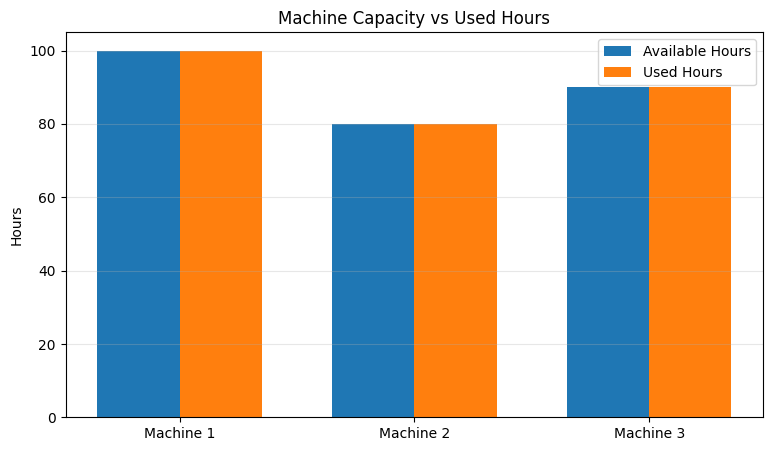

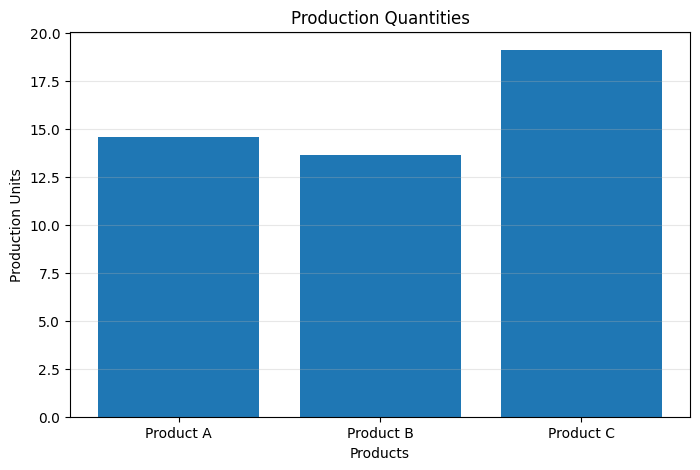

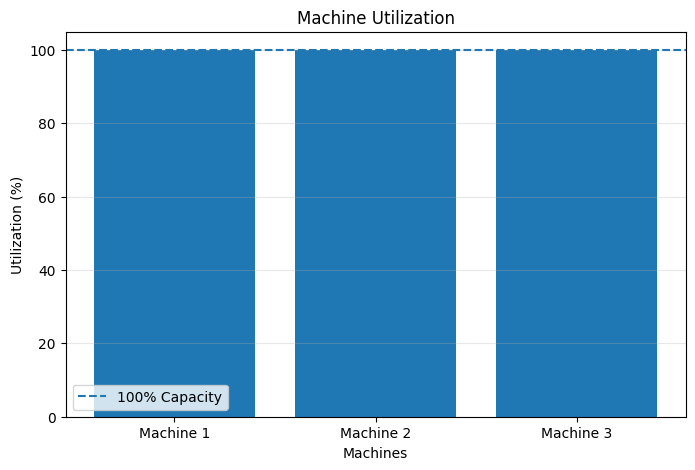

In [ ]:
# Cell 5: Visual charts

if production is not None:

    machine_usage = time_required @ production
    utilization = (machine_usage / available_hours) * 100

    # ---------- Chart 1: Machine Hours ----------
    x = np.arange(len(machines))
    width = 0.35

    plt.figure(figsize=(9, 5))

    plt.bar(
        x - width/2,
        available_hours,
        width,
        label="Available Hours"
    )

    plt.bar(
        x + width/2,
        machine_usage,
        width,
        label="Used Hours"
    )

    plt.xticks(x, machines)
    plt.ylabel("Hours")
    plt.title("Machine Capacity vs Used Hours")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)

    plt.show()

    # ---------- Chart 2: Production Quantities ----------
    plt.figure(figsize=(8, 5))

    plt.bar(products, production)

    plt.xlabel("Products")
    plt.ylabel("Production Units")
    plt.title("Production Quantities")

    plt.grid(axis="y", alpha=0.3)

    plt.show()

    # ---------- Chart 3: Machine Utilization ----------
    plt.figure(figsize=(8, 5))

    plt.bar(machines, utilization)

    plt.xlabel("Machines")
    plt.ylabel("Utilization (%)")
    plt.title("Machine Utilization")

    plt.axhline(100, linestyle="--", label="100% Capacity")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)

    plt.show()

else:
    print("Charts cannot be generated because the system is inconsistent.")

In [ ]:
# FACTORY PRODUCTION PLANNER - ONE CELL DEBUG VERSION

import numpy as np
import sympy as sp

# ---------- INPUTS ----------
products = ["Product A", "Product B", "Product C"]
machines = ["Machine 1", "Machine 2", "Machine 3"]

# Machine time required by each product
A = sp.Matrix([
    [2, 1, 3],
    [1, 2, 2],
    [3, 2, 1]
])

# Available machine hours
b = sp.Matrix([100, 80, 90])

# ---------- RANK & CONSISTENCY ----------
augmented = A.row_join(b)

rank_A = A.rank()
rank_aug = augmented.rank()

print("Coefficient Matrix A:")
sp.pprint(A)

print("\nAugmented Matrix [A|b]:")
sp.pprint(augmented)

print(f"\nRank(A)       = {rank_A}")
print(f"Rank([A|b])   = {rank_aug}")

if rank_A == rank_aug:
    print("\nSystem: CONSISTENT")

    solution = sp.linsolve((A, b))
    values = list(solution)[0]

    print("\nProduction quantities:")
    for product, value in zip(products, values):
        print(f"{product}: {float(value):.2f} units")

    # Check the mathematical solution
    usage = A * sp.Matrix(values)

    print("\nMachine usage:")
    for machine, used, available in zip(machines, usage, b):
        percentage = float(used / available * 100)
        print(f"{machine}: {float(used):.2f}/{float(available):.2f} hours ({percentage:.2f}%)")

    # Highest utilization = practical bottleneck
    utilization = [float(usage[i] / b[i] * 100) for i in range(3)]
    bottleneck = machines[np.argmax(utilization)]

    print(f"\nBottleneck: {bottleneck}")

else:
    print("\nSystem: INCONSISTENT")
    print("Rank(A) != Rank([A|b])")
    print("Therefore, there is no exact solution satisfying all equations.")

Coefficient Matrix A:
⎡2  1  3⎤
⎢       ⎥
⎢1  2  2⎥
⎢       ⎥
⎣3  2  1⎦

Augmented Matrix [A|b]:
⎡2  1  3  100⎤
⎢            ⎥
⎢1  2  2  80 ⎥
⎢            ⎥
⎣3  2  1  90 ⎦

Rank(A)       = 3
Rank([A|b])   = 3

System: CONSISTENT

Production quantities:
Product A: 14.55 units
Product B: 13.64 units
Product C: 19.09 units

Machine usage:
Machine 1: 100.00/100.00 hours (100.00%)
Machine 2: 80.00/80.00 hours (100.00%)
Machine 3: 90.00/90.00 hours (100.00%)

Bottleneck: Machine 1


       FACTORY PRODUCTION PLANNER (A7)
Team    : Team A7
Members : Member 1 | Member 2 | Member 3
College : B.Tech Mathematics Mini Project

COEFFICIENT MATRIX A:
⎡2  1  3⎤
⎢       ⎥
⎢1  2  2⎥
⎢       ⎥
⎣3  2  1⎦

AVAILABLE HOURS b:
⎡100⎤
⎢   ⎥
⎢80 ⎥
⎢   ⎥
⎣90 ⎦

RANK ANALYSIS
Rank(A)     = 3
Rank([A|b]) = 3

SYSTEM STATUS: CONSISTENT

PRODUCTION QUANTITIES
Product A: 14.55 units
Product B: 13.64 units
Product C: 19.09 units

MACHINE UTILIZATION
Machine 1: 100.00/100.00 hours (100.00%)
Machine 2: 80.00/80.00 hours (100.00%)
Machine 3: 90.00/90.00 hours (100.00%)

PRACTICAL INTERPRETATION
Bottleneck Machine: Machine 1
Highest utilization: 100.00%


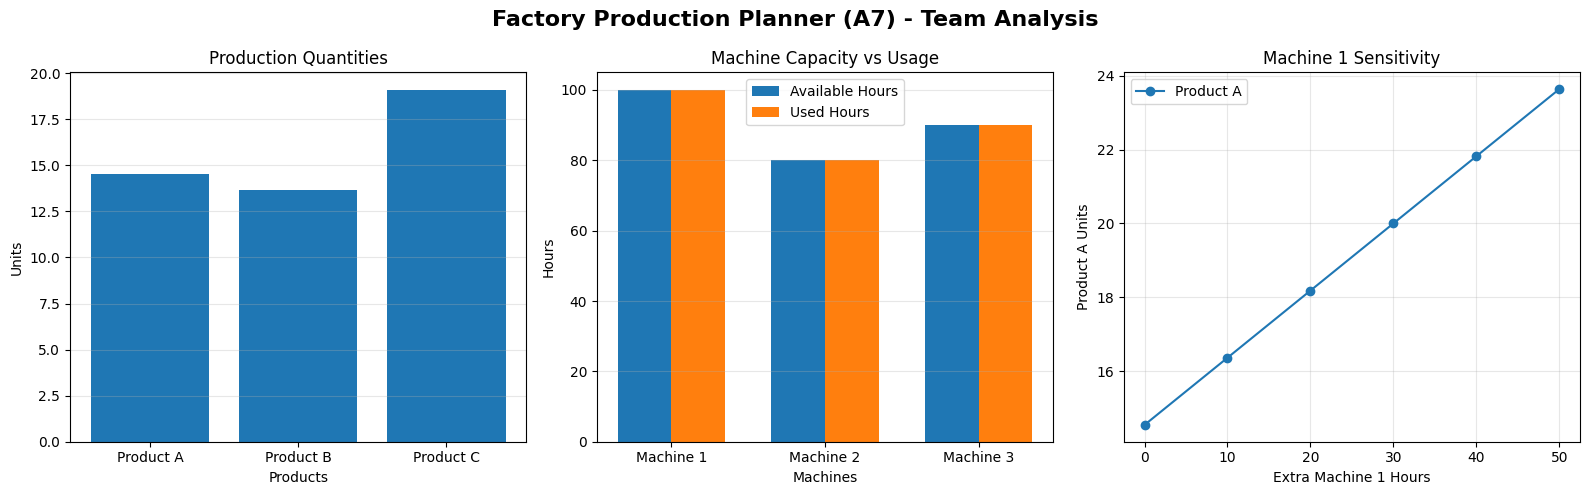

In [ ]:
# ============================================================
# FACTORY PRODUCTION PLANNER (A7) - CORRECTED VERSION
# ============================================================

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

# ---------- TEAM HEADER ----------
TEAM_NAME = "Team A7"
TEAM_MEMBERS = "Member 1 | Member 2 | Member 3"
COLLEGE = "B.Tech Mathematics Mini Project"

print("=" * 60)
print("       FACTORY PRODUCTION PLANNER (A7)")
print("=" * 60)
print(f"Team    : {TEAM_NAME}")
print(f"Members : {TEAM_MEMBERS}")
print(f"College : {COLLEGE}")
print("=" * 60)

# ---------- INPUT DATA ----------
products = ["Product A", "Product B", "Product C"]
machines = ["Machine 1", "Machine 2", "Machine 3"]

# Machine time required by each product
A = sp.Matrix([
    [2, 1, 3],
    [1, 2, 2],
    [3, 2, 1]
])

# Available machine hours
b = sp.Matrix([100, 80, 90])

# ---------- CONSISTENCY & RANK ----------
augmented = A.row_join(b)

rank_A = A.rank()
rank_augmented = augmented.rank()

print("\nCOEFFICIENT MATRIX A:")
sp.pprint(A)

print("\nAVAILABLE HOURS b:")
sp.pprint(b)

print("\nRANK ANALYSIS")
print("Rank(A)     =", rank_A)
print("Rank([A|b]) =", rank_augmented)

# ---------- CHECK CONSISTENCY ----------
if rank_A == rank_augmented:

    print("\nSYSTEM STATUS: CONSISTENT")

    # Solve Ax = b
    solution = list(sp.linsolve((A, b)))[0]

    # Convert SymPy solution to normal Python numbers
    production = np.array([float(v) for v in solution])

    print("\nPRODUCTION QUANTITIES")
    for product, quantity in zip(products, production):
        print(f"{product}: {quantity:.2f} units")

    # ---------- MACHINE USAGE ----------
    A_np = np.array(A.tolist(), dtype=float)
    b_np = np.array(b.tolist(), dtype=float).flatten()

    usage = A_np @ production
    utilization = (usage / b_np) * 100

    print("\nMACHINE UTILIZATION")

    for machine, used, available, percent in zip(
        machines, usage, b_np, utilization
    ):
        print(
            f"{machine}: {used:.2f}/{available:.2f} hours "
            f"({percent:.2f}%)"
        )

    # ---------- BOTTLENECK ----------
    bottleneck_index = np.argmax(utilization)
    bottleneck = machines[bottleneck_index]

    print("\nPRACTICAL INTERPRETATION")
    print(f"Bottleneck Machine: {bottleneck}")
    print(
        f"Highest utilization: "
        f"{utilization[bottleneck_index]:.2f}%"
    )

    # ---------- SENSITIVITY ANALYSIS ----------
    # Add extra hours to Machine 1 and observe Product A.
    extra_hours = np.arange(0, 51, 10)
    product_A_values = []

    for extra in extra_hours:

        new_b = b.copy()
        new_b[0] = new_b[0] + int(extra)

        new_solution = list(sp.linsolve((A, new_b)))[0]

        product_A_values.append(float(new_solution[0]))

    # ---------- CHARTS ----------
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Chart 1: Production
    axes[0].bar(products, production)
    axes[0].set_title("Production Quantities")
    axes[0].set_xlabel("Products")
    axes[0].set_ylabel("Units")
    axes[0].grid(axis="y", alpha=0.3)

    # Chart 2: Machine usage
    x = np.arange(len(machines))
    width = 0.35

    axes[1].bar(
        x - width / 2,
        b_np,
        width,
        label="Available Hours"
    )

    axes[1].bar(
        x + width / 2,
        usage,
        width,
        label="Used Hours"
    )

    axes[1].set_title("Machine Capacity vs Usage")
    axes[1].set_xlabel("Machines")
    axes[1].set_ylabel("Hours")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(machines)
    axes[1].legend()
    axes[1].grid(axis="y", alpha=0.3)

    # Chart 3: Sensitivity
    axes[2].plot(
        extra_hours,
        product_A_values,
        marker="o",
        label="Product A"
    )

    axes[2].set_title("Machine 1 Sensitivity")
    axes[2].set_xlabel("Extra Machine 1 Hours")
    axes[2].set_ylabel("Product A Units")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.suptitle(
        "Factory Production Planner (A7) - Team Analysis",
        fontsize=16,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

else:

    print("\nSYSTEM STATUS: INCONSISTENT")
    print("Rank(A) != Rank([A|b])")
    print("No exact solution satisfies all three equations.")

             FACTORY PRODUCTION PLANNER (A7)
                 MATHEMATICS MINI PROJECT
Team Name : ABHIYAN
Leader    : Leader Name & Roll No
Members   : Member 1 | Member 2 | Member 3

1. MATHEMATICAL MODEL
Let x, y, z represent units of Product A, B and C.

Equations:
2x + y + 3z = 100
x + 2y + 2z = 80
3x + 2y + z = 90

Coefficient Matrix A:
⎡2  1  3⎤
⎢       ⎥
⎢1  2  2⎥
⎢       ⎥
⎣3  2  1⎦

Available Hours Vector b:
⎡100⎤
⎢   ⎥
⎢80 ⎥
⎢   ⎥
⎣90 ⎦

2. CONSISTENCY & RANK ANALYSIS
Rank(A)       = 3
Rank([A | b]) = 3
System Status: CONSISTENT

3. PRODUCTION QUANTITIES
Product A: 14.55 units
Product B: 13.64 units
Product C: 19.09 units

4. MACHINE UTILIZATION
Machine 1: 100.00/100.00 hours (100.00%)
Machine 2: 80.00/80.00 hours (100.00%)
Machine 3: 90.00/90.00 hours (100.00%)

5. PRACTICAL INTERPRETATION
Bottleneck Machine: Machine 1
Highest utilization: 100.00%

6. SOLUTION VERIFICATION
✓ Production solution satisfies all machine equations.

7. SENSITIVITY ANALYSIS
Increasing Machine 1 h

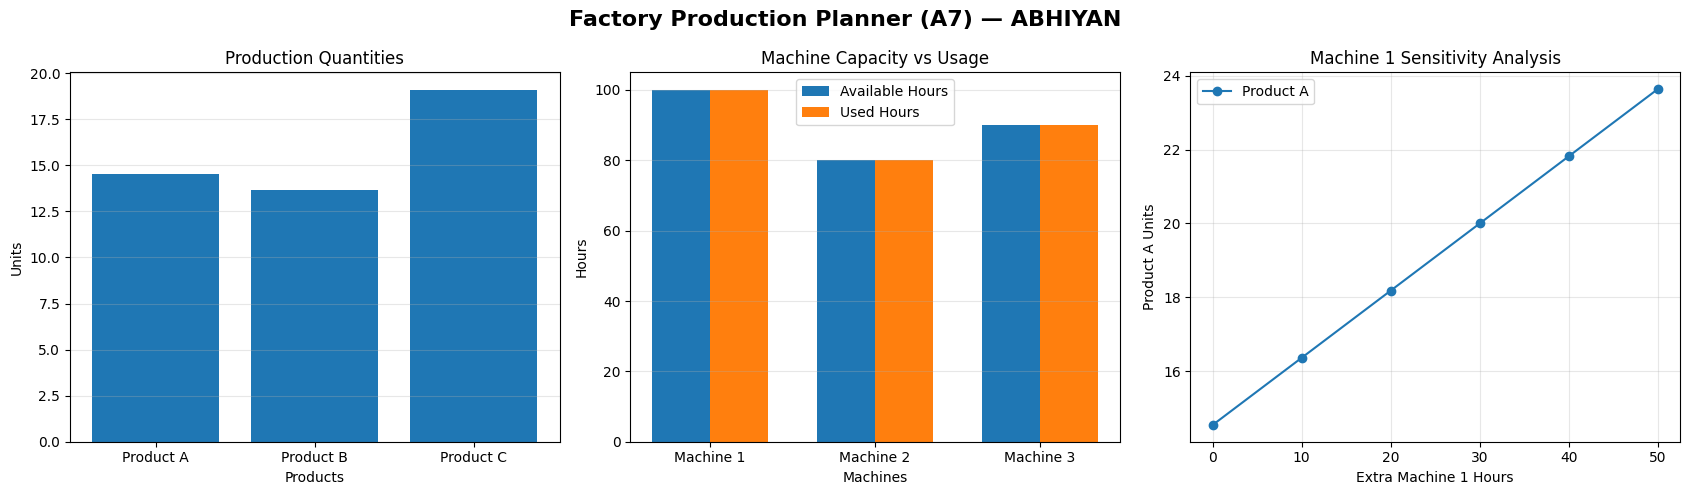


                    PROJECT SUMMARY
Mathematical Concept : Consistency + Rank Analysis
Application           : Factory Production Planning
Programming           : Python / SymPy / NumPy
Visualization         : Matplotlib
System                : Consistent
Bottleneck            : Machine 1


In [ ]:
# ============================================================
# FACTORY PRODUCTION PLANNER (A7)
# Mathematics Mini Project — ABHIYAN
# ============================================================

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

# ---------------- TEAM INFORMATION ----------------
TEAM_NAME = "ABHIYAN"
LEADER = "Leader Name & Roll No"
MEMBERS = "Member 1 | Member 2 | Member 3"

# ---------------- FACTORY INPUTS ----------------
products = ["Product A", "Product B", "Product C"]
machines = ["Machine 1", "Machine 2", "Machine 3"]

# Time required by each product on each machine
# Rows = Machines, Columns = Products
A = sp.Matrix([
    [2, 1, 3],
    [1, 2, 2],
    [3, 2, 1]
])

# Available hours of each machine
b = sp.Matrix([100, 80, 90])

# ---------------- PROJECT HEADER ----------------
print("=" * 70)
print("             FACTORY PRODUCTION PLANNER (A7)")
print("                 MATHEMATICS MINI PROJECT")
print("=" * 70)
print(f"Team Name : {TEAM_NAME}")
print(f"Leader    : {LEADER}")
print(f"Members   : {MEMBERS}")
print("=" * 70)

# ---------------- MATHEMATICAL MODEL ----------------
print("\n1. MATHEMATICAL MODEL")
print("Let x, y, z represent units of Product A, B and C.")

print("\nEquations:")
print("2x + y + 3z = 100")
print("x + 2y + 2z = 80")
print("3x + 2y + z = 90")

print("\nCoefficient Matrix A:")
sp.pprint(A)

print("\nAvailable Hours Vector b:")
sp.pprint(b)

# ---------------- CONSISTENCY & RANK ----------------
augmented = A.row_join(b)

rank_A = A.rank()
rank_augmented = augmented.rank()

print("\n2. CONSISTENCY & RANK ANALYSIS")
print(f"Rank(A)       = {rank_A}")
print(f"Rank([A | b]) = {rank_augmented}")

if rank_A == rank_augmented:
    print("System Status: CONSISTENT")

    # Solve Ax = b
    solution = list(sp.linsolve((A, b)))[0]
    production = np.array([float(value) for value in solution])

    # ---------------- PRODUCTION RESULT ----------------
    print("\n3. PRODUCTION QUANTITIES")

    for product, quantity in zip(products, production):
        print(f"{product}: {quantity:.2f} units")

    # ---------------- MACHINE USAGE ----------------
    A_np = np.array(A.tolist(), dtype=float)
    b_np = np.array(b.tolist(), dtype=float).flatten()

    machine_usage = A_np @ production
    utilization = (machine_usage / b_np) * 100

    print("\n4. MACHINE UTILIZATION")

    for machine, used, available, percent in zip(
        machines, machine_usage, b_np, utilization
    ):
        print(
            f"{machine}: {used:.2f}/{available:.2f} hours "
            f"({percent:.2f}%)"
        )

    # ---------------- BOTTLENECK ----------------
    bottleneck_index = np.argmax(utilization)
    bottleneck = machines[bottleneck_index]

    print("\n5. PRACTICAL INTERPRETATION")
    print(f"Bottleneck Machine: {bottleneck}")
    print(
        f"Highest utilization: "
        f"{utilization[bottleneck_index]:.2f}%"
    )

    # ---------------- VERIFICATION ----------------
    calculated_hours = A_np @ production

    print("\n6. SOLUTION VERIFICATION")

    if np.allclose(calculated_hours, b_np):
        print("✓ Production solution satisfies all machine equations.")
    else:
        print("✗ Verification failed.")

    # ---------------- SENSITIVITY ANALYSIS ----------------
    print("\n7. SENSITIVITY ANALYSIS")
    print("Increasing Machine 1 hours and observing Product A.")

    extra_hours = np.arange(0, 51, 10)
    product_A_values = []

    for extra in extra_hours:

        new_b = b.copy()
        new_b[0] += int(extra)

        new_solution = list(sp.linsolve((A, new_b)))[0]
        product_A_values.append(float(new_solution[0]))

    # ---------------- CHARTS ----------------
    fig, axes = plt.subplots(1, 3, figsize=(17, 5))

    # Chart 1: Production
    axes[0].bar(products, production)
    axes[0].set_title("Production Quantities")
    axes[0].set_xlabel("Products")
    axes[0].set_ylabel("Units")
    axes[0].grid(axis="y", alpha=0.3)

    # Chart 2: Machine capacity
    x = np.arange(len(machines))
    width = 0.35

    axes[1].bar(
        x - width / 2,
        b_np,
        width,
        label="Available Hours"
    )

    axes[1].bar(
        x + width / 2,
        machine_usage,
        width,
        label="Used Hours"
    )

    axes[1].set_title("Machine Capacity vs Usage")
    axes[1].set_xlabel("Machines")
    axes[1].set_ylabel("Hours")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(machines)
    axes[1].legend()
    axes[1].grid(axis="y", alpha=0.3)

    # Chart 3: Sensitivity
    axes[2].plot(
        extra_hours,
        product_A_values,
        marker="o",
        label="Product A"
    )

    axes[2].set_title("Machine 1 Sensitivity Analysis")
    axes[2].set_xlabel("Extra Machine 1 Hours")
    axes[2].set_ylabel("Product A Units")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.suptitle(
        "Factory Production Planner (A7) — ABHIYAN",
        fontsize=16,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

else:
    print("System Status: INCONSISTENT")
    print("Rank(A) != Rank([A | b])")
    print("No exact production solution exists.")

# ---------------- FINAL SUMMARY ----------------
print("\n" + "=" * 70)
print("                    PROJECT SUMMARY")
print("=" * 70)
print("Mathematical Concept : Consistency + Rank Analysis")
print("Application           : Factory Production Planning")
print("Programming           : Python / SymPy / NumPy")
print("Visualization         : Matplotlib")

if rank_A == rank_augmented:
    print(f"System                : Consistent")
    print(f"Bottleneck            : {bottleneck}")

print("=" * 70)

In [ ]:
# ============================================================
# FACTORY PRODUCTION PLANNER (A7)
# Mathematics Mini Project — ABHIYAN
# ============================================================

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

# -------------------- TEAM INFORMATION -----------------------

TEAM_NAME = "ABHIYAN"
LEADER = "Leader Name & Roll No"
MEMBERS = "Member 1 | Member 2 | Member 3"

print("=" * 65)
print("             FACTORY PRODUCTION PLANNER (A7)")
print("             MATHEMATICS MINI PROJECT")
print("=" * 65)
print("Team    :", TEAM_NAME)
print("Leader  :", LEADER)
print("Members :", MEMBERS)

# ============================================================
# 1. INPUT DATA
# ============================================================

products = ["Product A", "Product B", "Product C"]
machines = ["Machine 1", "Machine 2", "Machine 3"]

# Matrix:
# Rows    -> Machines
# Columns -> Products

A = sp.Matrix([
    [2, 1, 3],
    [1, 2, 2],
    [3, 2, 1]
])

# Available machine hours
b = sp.Matrix([100, 80, 90])

# ============================================================
# 2. MATHEMATICAL MODEL
# ============================================================

print("\n1. MATHEMATICAL MODEL")
print("-" * 65)

print("Let:")
print("x = Product A quantity")
print("y = Product B quantity")
print("z = Product C quantity")

print("\nEquations:")
print("2x + y + 3z = 100")
print("x + 2y + 2z = 80")
print("3x + 2y + z = 90")

# ============================================================
# 3. RANK & CONSISTENCY ANALYSIS
# ============================================================

rank_A = A.rank()
augmented_matrix = A.row_join(b)
rank_augmented = augmented_matrix.rank()

print("\n2. CONSISTENCY & RANK ANALYSIS")
print("-" * 65)

print("Coefficient Matrix A:")
sp.pprint(A)

print("\nAugmented Matrix [A | b]:")
sp.pprint(augmented_matrix)

print("\nRank(A)       =", rank_A)
print("Rank([A | b]) =", rank_augmented)

if rank_A == rank_augmented:
    print("System Status = CONSISTENT")
else:
    print("System Status = INCONSISTENT")

# ============================================================
# 4. SOLVE THE SYSTEM
# ============================================================

print("\n3. PRODUCTION QUANTITIES")
print("-" * 65)

solution_set = sp.linsolve((A, b))

if solution_set == sp.EmptySet:
    print("No solution exists.")
    raise SystemExit

solution_tuple = next(iter(solution_set))

# Convert SymPy values to

             FACTORY PRODUCTION PLANNER (A7)
             MATHEMATICS MINI PROJECT
Team    : ABHIYAN
Leader  : Leader Name & Roll No
Members : Member 1 | Member 2 | Member 3

1. MATHEMATICAL MODEL
-----------------------------------------------------------------
Let:
x = Product A quantity
y = Product B quantity
z = Product C quantity

Equations:
2x + y + 3z = 100
x + 2y + 2z = 80
3x + 2y + z = 90

2. CONSISTENCY & RANK ANALYSIS
-----------------------------------------------------------------
Coefficient Matrix A:
⎡2  1  3⎤
⎢       ⎥
⎢1  2  2⎥
⎢       ⎥
⎣3  2  1⎦

Augmented Matrix [A | b]:
⎡2  1  3  100⎤
⎢            ⎥
⎢1  2  2  80 ⎥
⎢            ⎥
⎣3  2  1  90 ⎦

Rank(A)       = 3
Rank([A | b]) = 3
System Status = CONSISTENT

3. PRODUCTION QUANTITIES
-----------------------------------------------------------------
